##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise 

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class** 

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold 
  - The model only detects objects from the **COCO dataset (80 classes)**  


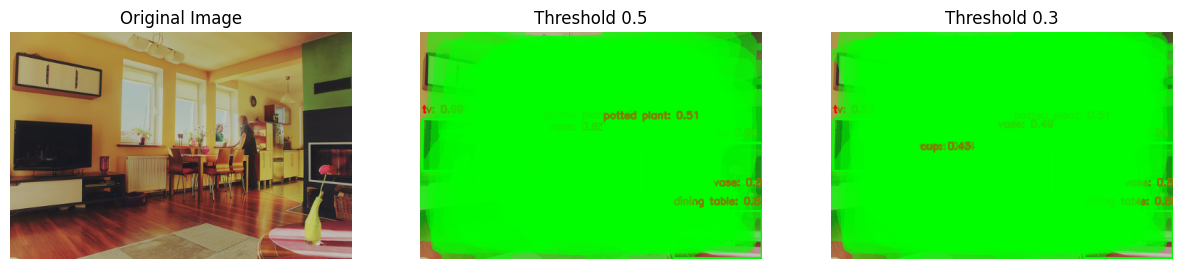

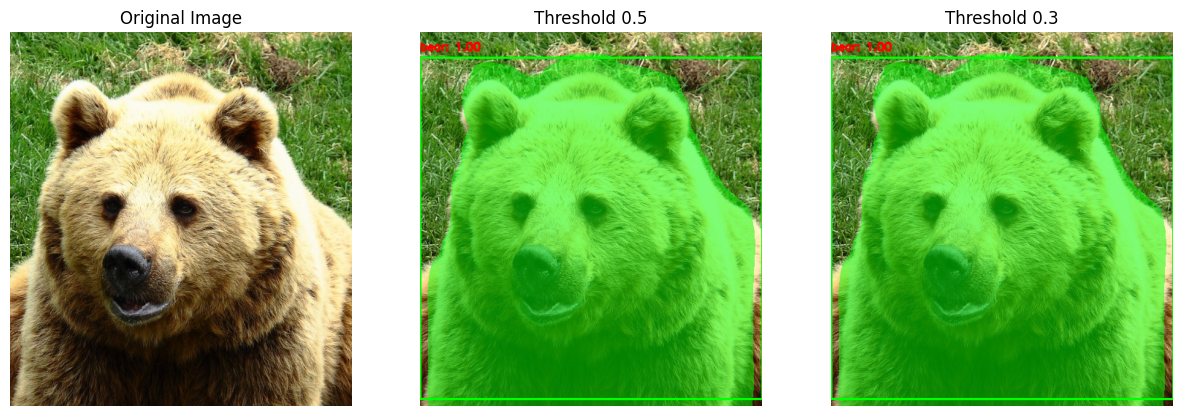

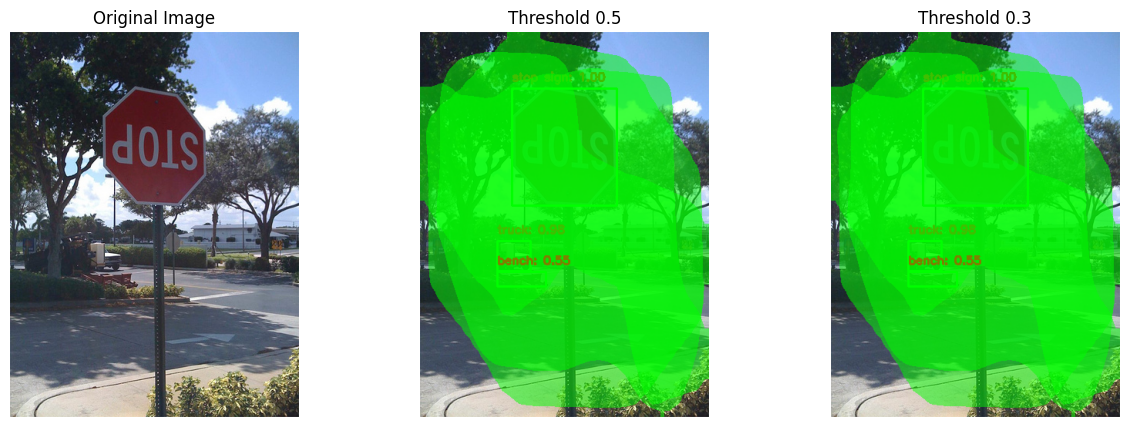

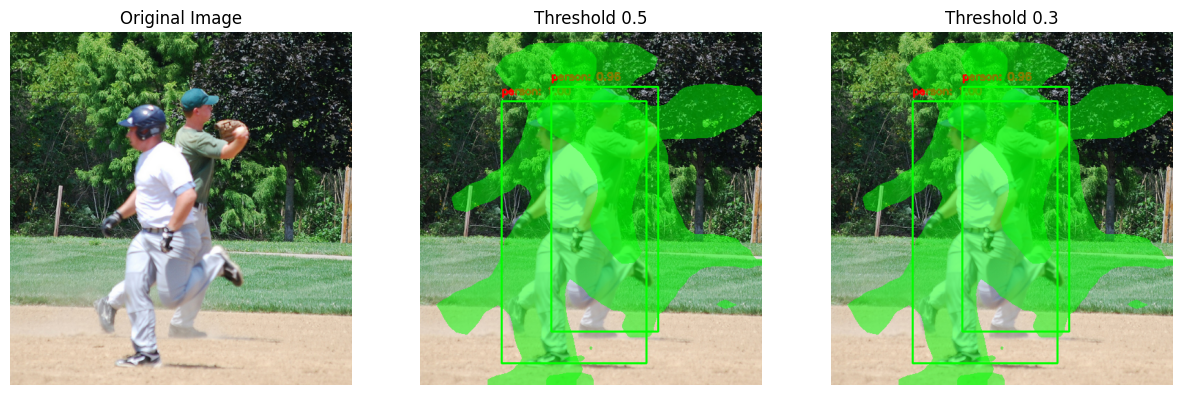

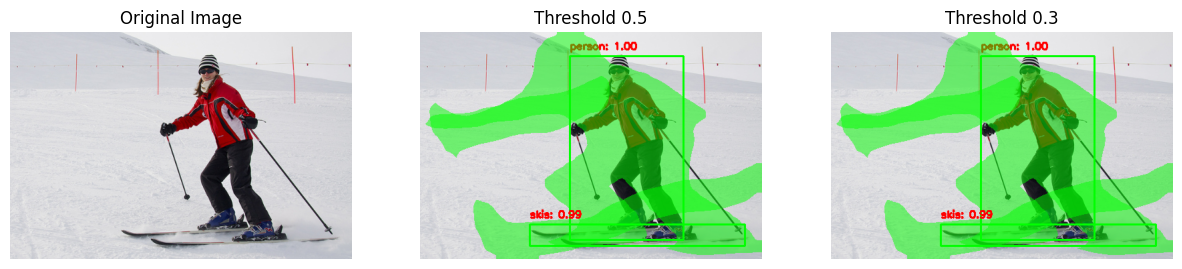

In [ ]:
# ==========================================================
# INSTANCE SEGMENTATION (Mask R-CNN) 
# ==========================================================


import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# ---------------------------
# 1. Import libraries
# ---------------------------
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt
import requests

# ---------------------------
# 2. Load pretrained model
# ---------------------------
model = hub.load("https://tfhub.dev/tensorflow/mask_rcnn/inception_resnet_v2_1024x1024/1")

# ---------------------------
# 3. COCO class names (80 classes)
# ---------------------------
COCO_CLASSES = [
'background','person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
'traffic light','fire hydrant','N/A','stop sign','parking meter','bench','bird','cat','dog','horse',
'sheep','cow','elephant','bear','zebra','giraffe','N/A','backpack','umbrella','N/A','N/A',
'handbag','tie','suitcase','frisbee','skis','snowboard','sports ball','kite','baseball bat',
'baseball glove','skateboard','surfboard','tennis racket','bottle','N/A','wine glass','cup',
'fork','knife','spoon','bowl','banana','apple','sandwich','orange','broccoli','carrot','hot dog',
'pizza','donut','cake','chair','couch','potted plant','bed','N/A','dining table','N/A','N/A',
'toilet','N/A','tv','laptop','mouse','remote','keyboard','cell phone','microwave','oven',
'toaster','sink','refrigerator','N/A','book','clock','vase','scissors','teddy bear','hair drier','toothbrush'
]

# ---------------------------
# 4. Load images from COCO
# ---------------------------
def load_image(url):
    resp = requests.get(url)
    img = np.asarray(bytearray(resp.content), dtype="uint8")
    img = cv2.imdecode(img, cv2.IMREAD_COLOR)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

urls = [
    "http://images.cocodataset.org/val2017/000000000139.jpg",
    "http://images.cocodataset.org/val2017/000000000285.jpg",
    "http://images.cocodataset.org/val2017/000000000724.jpg",
    "http://images.cocodataset.org/val2017/000000000872.jpg",
    "http://images.cocodataset.org/val2017/000000000785.jpg"
]

images = [load_image(u) for u in urls]

# ---------------------------
# 5. Resize images (reduce crashes)
# ---------------------------
def resize_image(img, max_size=512):
    h, w, _ = img.shape
    scale = max_size / max(h, w)
    if scale < 1:
        img = cv2.resize(img, (int(w*scale), int(h*scale)))
    return img

images = [resize_image(img) for img in images]

# ---------------------------
# 6. Run inference
# ---------------------------
def run_inference(image):
    image_tensor = tf.convert_to_tensor(image, dtype=tf.uint8)
    image_tensor = tf.expand_dims(image_tensor, axis=0)
    outputs = model(image_tensor)
    return {k: v.numpy() for k, v in outputs.items()}

# ---------------------------
# 7. Visualization with class names
# ---------------------------
def visualize(image, outputs, threshold=0.5):
    h, w, _ = image.shape
    output = image.copy()

    boxes = outputs['detection_boxes'][0]
    classes = outputs['detection_classes'][0].astype(int)
    scores = outputs['detection_scores'][0]
    masks = outputs['detection_masks'][0]

    for i in range(len(scores)):
        if scores[i] < threshold:
            continue

        y1, x1, y2, x2 = boxes[i]
        y1, x1, y2, x2 = int(y1*h), int(x1*w), int(y2*h), int(x2*w)

        class_id = classes[i]
        class_name = COCO_CLASSES[class_id]

        # Draw bounding box
        cv2.rectangle(output, (x1, y1), (x2, y2), (0,255,0), 2)

        # Show class name + confidence
        label = f"{class_name}: {scores[i]:.2f}"
        cv2.putText(output, label, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)

        # Mask
        mask = masks[i]
        mask = cv2.resize(mask, (w, h))
        mask = mask > 0.5
        output[mask] = output[mask]*0.5 + np.array([0,255,0])*0.5

    return output

# ---------------------------
# 8. Run and display
# ---------------------------
for i, img in enumerate(images):

    outputs = run_inference(img)

    result_05 = visualize(img, outputs, 0.5)
    result_03 = visualize(img, outputs, 0.3)

    plt.figure(figsize=(15,5))

    # ORIGINAL IMAGE
    plt.subplot(1,3,1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis("off")

    # Threshold 0.5
    plt.subplot(1,3,2)
    plt.title("Threshold 0.5")
    plt.imshow(result_05)
    plt.axis("off")

    # Threshold 0.3
    plt.subplot(1,3,3)
    plt.title("Threshold 0.3")
    plt.imshow(result_03)
    plt.axis("off")

    plt.show()



Image 1 - Indoor Scene

Mixed lighting (natural + indoor) affects detection quality
Strong over-segmentation (mask covers most of the image)
Some objects detected correctly (table, cup, plant)
Poor boundary separation between objects
Performance decreases in cluttered indoor environments

Image 2 - Bear

Correct detection with very high confidence (~1.00)
Accurate and clean segmentation mask
Clear object with simple background improves performance
No significant difference between thresholds (0.5 vs 0.3)

Image 3 - Stop Sign

Correct detection of stop sign
Additional objects detected (some may be false positives)
Mask spreads beyond object - over-segmentation
Strong lighting and shadows affect accuracy
Lower threshold increases incorrect detections

Image 4 - Baseball Players

Successfully detects multiple persons 
Handles occlusion reasonably (players overlapping)
Masks are noisy and not well-defined
Some background included in segmentation
Lower threshold adds more noise

Image 5 - Skier

Correct detection of person and skis
High confidence predictions (~1.00)
Good segmentation but slightly over-extended mask
Works well with simple background (snow)
Unusual angle (side view) slightly affects mask precision